# NodeSTID Explainability: Layer-wise t-SNE Analysis

This notebook provides a detailed explainability analysis of:
1. **Pretrained NodeSTIDv2** (combined pretraining on PEMS08+03+04+07)
2. **NodeSTIDGraphConditioned** (graph-conditioned finetuning on PEMS08)

We visualize intermediate representations at every layer using t-SNE to understand:
- How embeddings evolve through the network
- How the backbone encoder transforms node representations
- How graph conditioning layers add spatial structure
- The effect of each component (temporal, dataset ID, graph)

In [28]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Setup paths
os.chdir('/home/jatin/BasicTS')
sys.path.insert(0, '/home/jatin/BasicTS')

from basicts.utils import load_adj
from baselines.NodeSTID.arch import NodeSTIDv2, NodeSTIDGraphConditioned

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda:3


## 1. Load Models and Data

In [29]:
# ===================== Load PEMS08 data =====================
import json

with open('datasets/PEMS08/desc.json') as f:
    desc = json.load(f)
T, N_nodes, C = desc['shape']

data = np.memmap('datasets/PEMS08/data.dat', dtype='float32', mode='r', shape=(T, N_nodes, C))
print(f'PEMS08 data shape: {data.shape}')  # [17856, 170, 3]
NUM_NODES = N_nodes  # 170

# Use test split (last 20%)
test_start = int(T * 0.8)
test_data = data[test_start:]  # [T_test, 170, 3]
print(f'Test data shape: {test_data.shape}')

# Load adjacency matrix
adj_mx, _ = load_adj('datasets/PEMS08/adj_mx.pkl', 'doubletransition')
print(f'Number of adjacency matrices: {len(adj_mx)}')

PEMS08 data shape: (17856, 170, 3)
Test data shape: (3572, 170, 3)
Number of adjacency matrices: 2


In [30]:
# ===================== Prepare a batch of test samples =====================
# Take multiple time windows covering all 170 nodes for the spatial view
INPUT_LEN = 12
OUTPUT_LEN = 12

# Select 32 evenly spaced time windows from the test set
num_windows = 32
max_start = test_data.shape[0] - INPUT_LEN - OUTPUT_LEN
window_starts = np.linspace(0, max_start, num_windows, dtype=int)

# Build batch: [num_windows, INPUT_LEN, NUM_NODES, 3]
batch_list = []
for s in window_starts:
    batch_list.append(test_data[s:s+INPUT_LEN])  # [12, 170, 3]

batch_np = np.stack(batch_list, axis=0)  # [32, 12, 170, 3]
batch = torch.tensor(batch_np, dtype=torch.float32).to(device)
print(f'Input batch shape: {batch.shape}')  # [32, 12, 170, 3]

Input batch shape: torch.Size([32, 12, 170, 3])


In [31]:
# ===================== Model parameters =====================
model_args = dict(
    input_len=INPUT_LEN, input_dim=3, embed_dim=32, output_len=OUTPUT_LEN,
    num_layer=3, if_T_i_D=True, if_D_i_W=True,
    if_dataset_id=True, temp_dim_tid=32, temp_dim_diw=32,
    time_of_day_size=288, day_of_week_size=7,
    num_datasets=4, dataset_id_dim=32,
)

PRETRAINED_CKPT = 'checkpoints/NodeSTIDv2/PEMS_Combined_v2_100_12_12/ed4bbd9b3ecee86e4f415b9c584b6b99/NodeSTIDv2_best_val_MAE.pt'
GC_CKPT = 'checkpoints/NodeSTIDGraphConditioned/PEMS08_100_12_12/db1ca4471424ab0663d0d5624b087a79/NodeSTIDGraphConditioned_best_val_MAE.pt'

print(f'Pretrained ckpt exists: {os.path.exists(PRETRAINED_CKPT)}')
print(f'GraphConditioned ckpt exists: {os.path.exists(GC_CKPT)}')

Pretrained ckpt exists: True
GraphConditioned ckpt exists: True


In [32]:
# ===================== Load Pretrained NodeSTIDv2 =====================
pretrained_model = NodeSTIDv2(**model_args).to(device)
ckpt = torch.load(PRETRAINED_CKPT, map_location=device)
state_dict = ckpt.get('model_state_dict', ckpt)
# Remove 'model.' prefix if present
clean_state = {k.replace('model.', ''): v for k, v in state_dict.items()}
pretrained_model.load_state_dict(clean_state, strict=True)
pretrained_model.eval()
print('Pretrained NodeSTIDv2 loaded.')

# ===================== Load Graph Conditioned Model =====================
gc_args = dict(
    **model_args,
    num_nodes=NUM_NODES,
    freeze_backbone=True,
    default_dataset_id=0,
    supports=[torch.tensor(a) for a in adj_mx],
    use_adaptive_adj=True,
    node_emb_dim=10,
    num_graph_layers=3,
    gcn_order=2,
    gcn_dropout=0.1,
)
gc_model = NodeSTIDGraphConditioned(**gc_args).to(device)
gc_ckpt = torch.load(GC_CKPT, map_location=device)
gc_state = gc_ckpt.get('model_state_dict', gc_ckpt)
gc_clean = {k.replace('model.', ''): v for k, v in gc_state.items()}
gc_model.load_state_dict(gc_clean, strict=True)
gc_model.eval()
print('NodeSTIDGraphConditioned loaded.')

Pretrained NodeSTIDv2 loaded.
NodeSTIDGraphConditioned loaded.


## 2. Extract Intermediate Representations

We hook into every layer to capture intermediate activations:

**Pretrained Backbone (NodeSTIDv2):**
1. Raw time series embedding (Conv2d projection)
2. Time-of-day embedding lookup
3. Day-of-week embedding lookup
4. Dataset ID embedding lookup
5. Concatenated embedding (all 4 combined)
6. After Encoder Layer 0
7. After Encoder Layer 1
8. After Encoder Layer 2

**Graph Conditioned (adds):**
9. After Graph Block 0 (GCN + MLP)
10. After Graph Block 1
11. After Graph Block 2
12. Final regression output

In [33]:
def extract_pretrained_representations(model, history_data):
    """
    Extract layer-by-layer representations from NodeSTIDv2.
    Input: history_data [B, L, 1, C] (node-wise, single node at a time)
    Returns dict of {layer_name: tensor [B, dim]}
    """
    reps = {}
    with torch.no_grad():
        input_data = history_data[..., :model.input_dim]  # [B, L, 1, 3]
        
        # 1. Time-of-day embedding
        t_i_d_data = history_data[..., 1]  # [B, L, 1]
        tid_idx = (t_i_d_data[:, -1, :] * model.time_of_day_size).long()
        time_in_day_emb = model.time_in_day_emb[tid_idx]  # [B, 1, tid_dim]
        reps['Time-of-Day Emb'] = time_in_day_emb.squeeze(1)  # [B, tid_dim]
        
        # 2. Day-of-week embedding
        d_i_w_data = history_data[..., 2]  # [B, L, 1]
        diw_idx = (d_i_w_data[:, -1, :] * model.day_of_week_size).long()
        day_in_week_emb = model.day_in_week_emb[diw_idx]  # [B, 1, diw_dim]
        reps['Day-of-Week Emb'] = day_in_week_emb.squeeze(1)  # [B, diw_dim]
        
        # 3. Dataset ID embedding
        ds_ids = history_data[:, -1, :, 3].long() if history_data.shape[-1] > 3 else torch.zeros(history_data.shape[0], 1, dtype=torch.long, device=history_data.device)
        dataset_emb = model.dataset_id_emb[ds_ids]  # [B, 1, ds_dim]
        reps['Dataset-ID Emb'] = dataset_emb.squeeze(1)  # [B, ds_dim]
        
        # 4. Time series embedding
        B, _, num_nodes, _ = input_data.shape
        x = input_data.transpose(1, 2).contiguous()  # [B, 1, L, 3]
        x = x.view(B, num_nodes, -1).transpose(1, 2).unsqueeze(-1)  # [B, L*3, 1, 1]
        time_series_emb = model.time_series_emb_layer(x)  # [B, embed_dim, 1, 1]
        reps['Time-Series Emb'] = time_series_emb.squeeze(-1).squeeze(-1)  # [B, embed_dim]
        
        # 5. Concatenated embedding
        embeddings = [
            time_series_emb,
            time_in_day_emb.transpose(1, 2).unsqueeze(-1),
            day_in_week_emb.transpose(1, 2).unsqueeze(-1),
            dataset_emb.transpose(1, 2).unsqueeze(-1),
        ]
        hidden = torch.cat(embeddings, dim=1)  # [B, hidden_dim, 1, 1]
        reps['Concatenated Emb'] = hidden.squeeze(-1).squeeze(-1)  # [B, hidden_dim]
        
        # 6-8. After each encoder layer
        for i, layer in enumerate(model.encoder):
            hidden = layer(hidden)
            reps[f'Encoder Layer {i}'] = hidden.squeeze(-1).squeeze(-1).clone()
        
        # 9. Final regression output
        prediction = model.regression_layer(hidden)  # [B, output_len, 1, 1]
        reps['Regression Output'] = prediction.squeeze(-1).squeeze(-1)  # [B, output_len]
    
    return reps


def extract_gc_representations(model, history_data):
    """
    Extract layer-by-layer representations from NodeSTIDGraphConditioned.
    Input: history_data [B, L, N, C] (full graph)
    Returns dict of {layer_name: tensor [B*N, dim] or [B, dim, N]}
    """
    reps = {}
    B, L, N, C = history_data.shape
    
    with torch.no_grad():
        input_data = history_data[..., :model.input_dim]  # [B, L, N, 3]
        
        # 1. Time-of-day embedding
        t_i_d = history_data[..., 1]  # [B, L, N]
        tid_idx = (t_i_d[:, -1, :] * model.time_of_day_size).long()
        time_in_day_emb = model.time_in_day_emb[tid_idx]  # [B, N, tid_dim]
        reps['Time-of-Day Emb'] = time_in_day_emb  # [B, N, tid_dim]
        
        # 2. Day-of-week embedding
        d_i_w = history_data[..., 2]
        diw_idx = (d_i_w[:, -1, :] * model.day_of_week_size).long()
        day_in_week_emb = model.day_in_week_emb[diw_idx]  # [B, N, diw_dim]
        reps['Day-of-Week Emb'] = day_in_week_emb
        
        # 3. Dataset ID embedding
        ds_ids = torch.full((B, N), model.default_dataset_id,
                            dtype=torch.long, device=history_data.device)
        dataset_emb = model.dataset_id_emb[ds_ids]  # [B, N, ds_dim]
        reps['Dataset-ID Emb'] = dataset_emb
        
        # 4. Time series embedding
        x = input_data.transpose(1, 2).contiguous()  # [B, N, L, 3]
        x = x.view(B, N, -1).transpose(1, 2).unsqueeze(-1)  # [B, L*3, N, 1]
        time_series_emb = model.time_series_emb_layer(x)  # [B, embed_dim, N, 1]
        reps['Time-Series Emb'] = time_series_emb.squeeze(-1).permute(0, 2, 1)  # [B, N, embed_dim]
        
        # 5. Concatenated embedding
        embeddings = [
            time_series_emb,
            time_in_day_emb.transpose(1, 2).unsqueeze(-1),
            day_in_week_emb.transpose(1, 2).unsqueeze(-1),
            dataset_emb.transpose(1, 2).unsqueeze(-1),
        ]
        hidden = torch.cat(embeddings, dim=1)  # [B, hidden_dim, N, 1]
        reps['Concatenated Emb'] = hidden.squeeze(-1).permute(0, 2, 1)  # [B, N, hidden_dim]
        
        # 6-8. Backbone encoder layers
        for i, layer in enumerate(model.encoder):
            hidden = layer(hidden)
            reps[f'Encoder Layer {i}'] = hidden.squeeze(-1).permute(0, 2, 1).clone()  # [B, N, hidden_dim]
        
        # 9. Project if needed
        if model.proj is not None:
            hidden = model.proj(hidden)
            reps['Projection'] = hidden.squeeze(-1).permute(0, 2, 1).clone()
        
        # 10-12. Graph conditioning blocks
        supports = model._get_supports()
        for i, block in enumerate(model.graph_blocks):
            hidden = block(hidden, supports)
            reps[f'Graph Block {i}'] = hidden.squeeze(-1).permute(0, 2, 1).clone()  # [B, N, hidden_dim]
        
        # 13. Regression output
        prediction = model.regression_layer(hidden)  # [B, output_len, N, 1]
        reps['Regression Output'] = prediction.squeeze(-1).permute(0, 2, 1)  # [B, N, output_len]
    
    return reps

print('Extraction functions defined.')

Extraction functions defined.


## 3. Run Extraction on Test Data

In [34]:
# ===================== Extract from Graph Conditioned model =====================
# This model takes [B, L, N, C] with C=3 (uses default_dataset_id=0)
gc_reps = extract_gc_representations(gc_model, batch)  # batch: [32, 12, 170, 3]

print('\nGraph Conditioned representations extracted:')
for name, tensor in gc_reps.items():
    print(f'  {name:25s} -> {list(tensor.shape)}')


Graph Conditioned representations extracted:
  Time-of-Day Emb           -> [32, 170, 32]
  Day-of-Week Emb           -> [32, 170, 32]
  Dataset-ID Emb            -> [32, 170, 32]
  Time-Series Emb           -> [32, 170, 32]
  Concatenated Emb          -> [32, 170, 128]
  Encoder Layer 0           -> [32, 170, 128]
  Encoder Layer 1           -> [32, 170, 128]
  Encoder Layer 2           -> [32, 170, 128]
  Graph Block 0             -> [32, 170, 128]
  Graph Block 1             -> [32, 170, 128]
  Graph Block 2             -> [32, 170, 128]
  Regression Output         -> [32, 170, 12]


In [35]:
# ===================== Extract from Pretrained model (node-wise) =====================
# NodeSTIDv2 expects [B, L, 1, C] with C=4 (dataset_id as channel 3)
# We'll process all 170 nodes across a few time windows

# Pick a single time window and treat each node as a separate sample
single_window = batch[0:1]  # [1, 12, 170, 3]

# Reshape: treat each node as a separate batch sample
# [170, 12, 1, 4] — append dataset_id=0 as channel 3
sw = single_window.squeeze(0).permute(1, 0, 2)  # [170, 12, 3]
sw = sw.unsqueeze(2)  # [170, 12, 1, 3]
# Append dataset_id = 0
ds_channel = torch.zeros(170, 12, 1, 1, device=device)
sw_with_dsid = torch.cat([sw, ds_channel], dim=-1)  # [170, 12, 1, 4]

pretrained_reps = extract_pretrained_representations(pretrained_model, sw_with_dsid)

print('Pretrained NodeSTIDv2 representations extracted:')
for name, tensor in pretrained_reps.items():
    print(f'  {name:25s} -> {list(tensor.shape)}')

Pretrained NodeSTIDv2 representations extracted:
  Time-of-Day Emb           -> [170, 32]
  Day-of-Week Emb           -> [170, 32]
  Dataset-ID Emb            -> [170, 32]
  Time-Series Emb           -> [170, 32]
  Concatenated Emb          -> [170, 128]
  Encoder Layer 0           -> [170, 128]
  Encoder Layer 1           -> [170, 128]
  Encoder Layer 2           -> [170, 128]
  Regression Output         -> [170, 12]


## 4. t-SNE Visualization Utilities

In [36]:
def compute_tsne(features, perplexity=30, random_state=42):
    """Compute t-SNE on feature matrix [N, D] -> [N, 2]."""
    n_samples = features.shape[0]
    perp = min(perplexity, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=random_state,
                max_iter=1000, learning_rate='auto', init='pca')
    return tsne.fit_transform(features)


def get_node_colors(num_nodes):
    """
    Assign colors to nodes based on their mean traffic flow.
    This helps visualize spatial structure in embeddings.
    """
    # Use mean flow of each node across test set as a continuous attribute
    node_mean_flow = test_data[:, :, 0].mean(axis=0)  # [N]
    return node_mean_flow


def get_time_colors(batch_data):
    """
    Get time-of-day labels for coloring.
    """
    tod = batch_data[:, -1, 0, 1]  # [B] last timestep, first node, tod channel
    return (tod.cpu().numpy() * 288).astype(int)  # time slot index


node_flow = get_node_colors(NUM_NODES)
# Normalize for color mapping
node_flow_norm = (node_flow - node_flow.min()) / (node_flow.max() - node_flow.min())
print(f'Node flow range: [{node_flow.min():.1f}, {node_flow.max():.1f}]')
print(f'Color array shape: {node_flow_norm.shape}')

Node flow range: [8.8, 461.6]
Color array shape: (170,)


## 5. Pretrained NodeSTIDv2: Layer-wise t-SNE

Each point = one of the 170 nodes (from the same time window).  
Color = mean traffic flow of the node (captures spatial identity).  
We expect embeddings to progressively cluster nodes with similar traffic patterns.

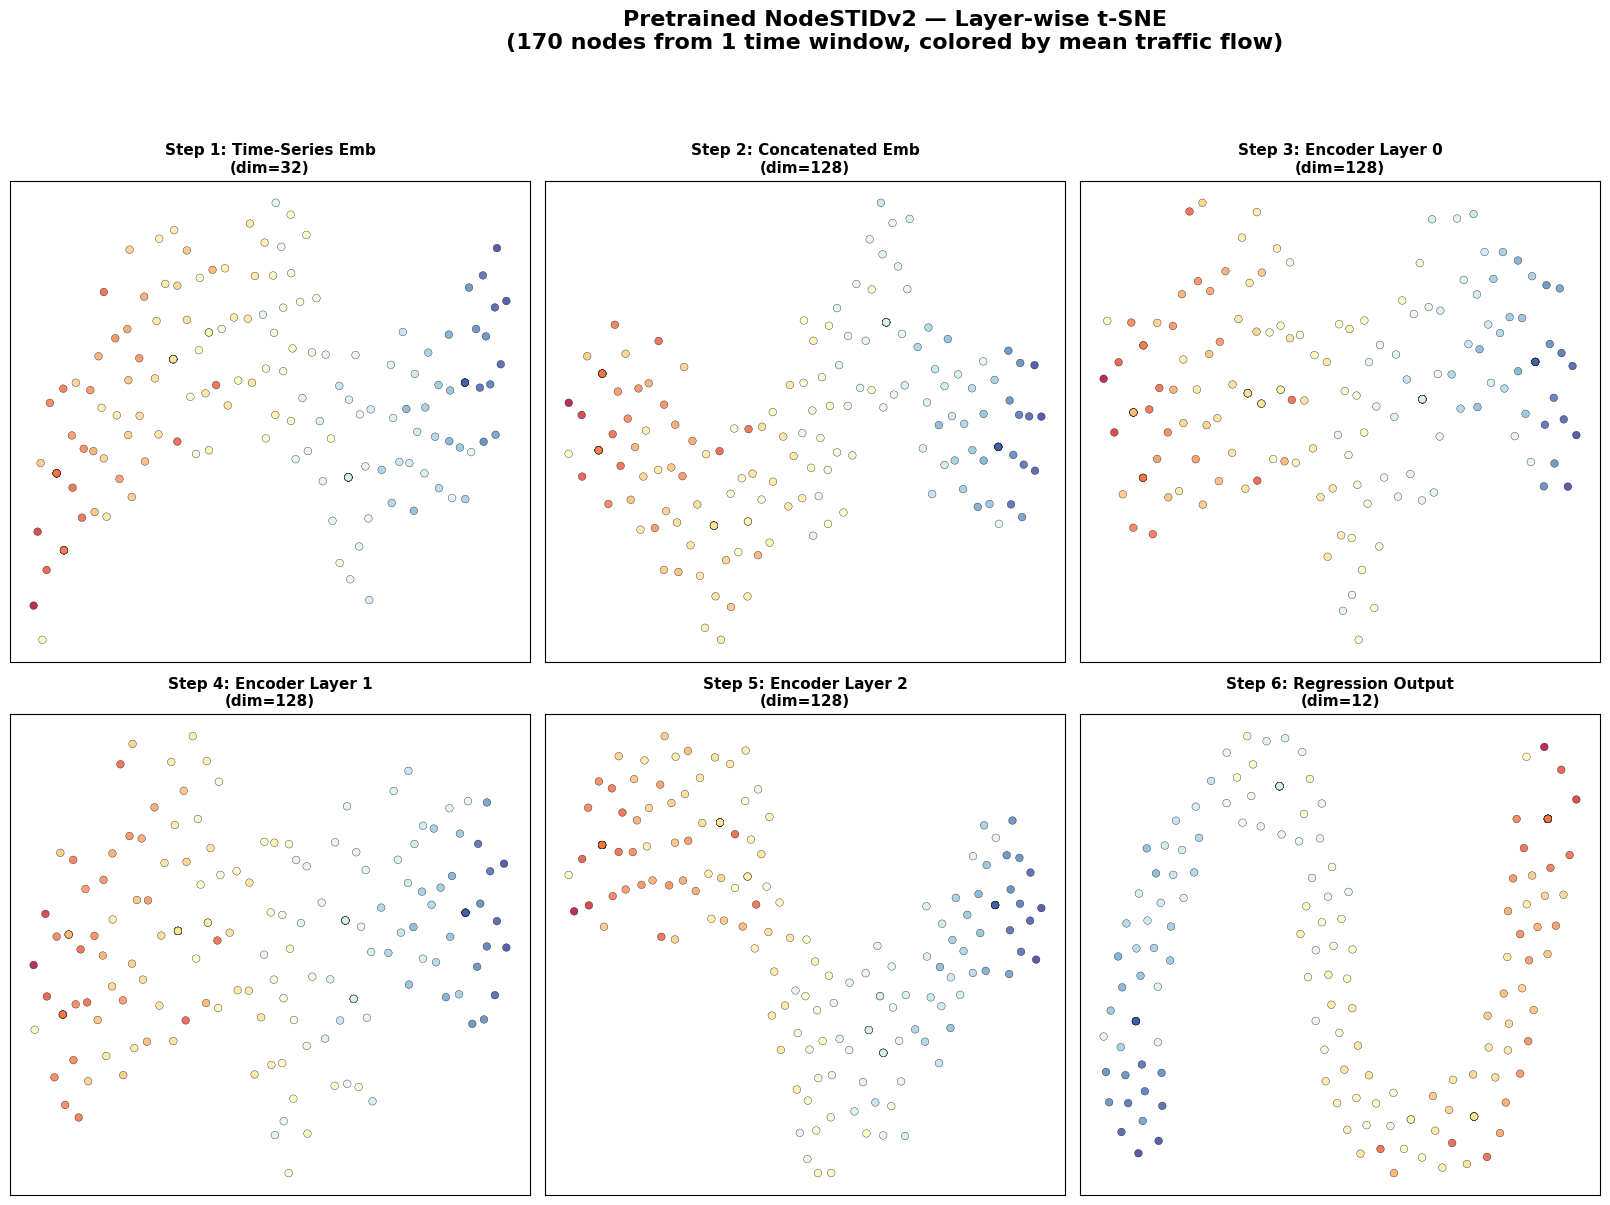

Saved: notebooks/pretrained_tsne_layerwise.png

Note: ToD, DoW, Dataset-ID embeddings are excluded — they are shared
across all nodes at the same timestep (only differ across time windows).


In [49]:
# ===================== Pretrained: Layer-wise t-SNE plot =====================
# Each sample = 1 node (170 total), colored by mean traffic flow
# NOTE: ToD, DoW, DatasetID embeddings are SHARED across all nodes in the same
# time window (they depend only on time, not on node identity), so we skip them
# here and only show layers where node representations actually differ.

layer_names_pretrained = [
    'Time-Series Emb', 'Concatenated Emb',
    'Encoder Layer 0', 'Encoder Layer 1', 'Encoder Layer 2',
    'Regression Output'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Pretrained NodeSTIDv2 — Layer-wise t-SNE\n(170 nodes from 1 time window, colored by mean traffic flow)',
             fontsize=16, fontweight='bold', y=1.0)

for idx, (name, ax) in enumerate(zip(layer_names_pretrained, axes.flat)):
    feat = pretrained_reps[name].cpu().numpy()  # [170, D]
    
    # Skip if feature dim < 2
    if feat.shape[1] < 2:
        ax.text(0.5, 0.5, f'{name}\n(dim={feat.shape[1]}, skip)',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title(name, fontsize=12)
        continue
    
    tsne_result = compute_tsne(feat)
    scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1],
                         c=node_flow_norm, cmap='RdYlBu_r', s=30, alpha=0.8, edgecolors='k', linewidths=0.3)
    ax.set_title(f'Step {idx+1}: {name}\n(dim={feat.shape[1]})', fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

# Add colorbar
# cbar = fig.colorbar(scatter, ax=axes, shrink=0.6, pad=0.04)
# cbar.set_label('Mean Traffic Flow (normalized)', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.90, 0.95])
plt.savefig('notebooks/pretrained_tsne_layerwise.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/pretrained_tsne_layerwise.png')
print('\nNote: ToD, DoW, Dataset-ID embeddings are excluded — they are shared')
print('across all nodes at the same timestep (only differ across time windows).')

## 6. Graph Conditioned Model: Layer-wise t-SNE

Here we visualize how the graph conditioning layers progressively inject spatial structure.  
Each point = one node. We average across the batch dimension.  
The key transition should be visible **after Graph Block layers** — GCN mixes information across nodes.

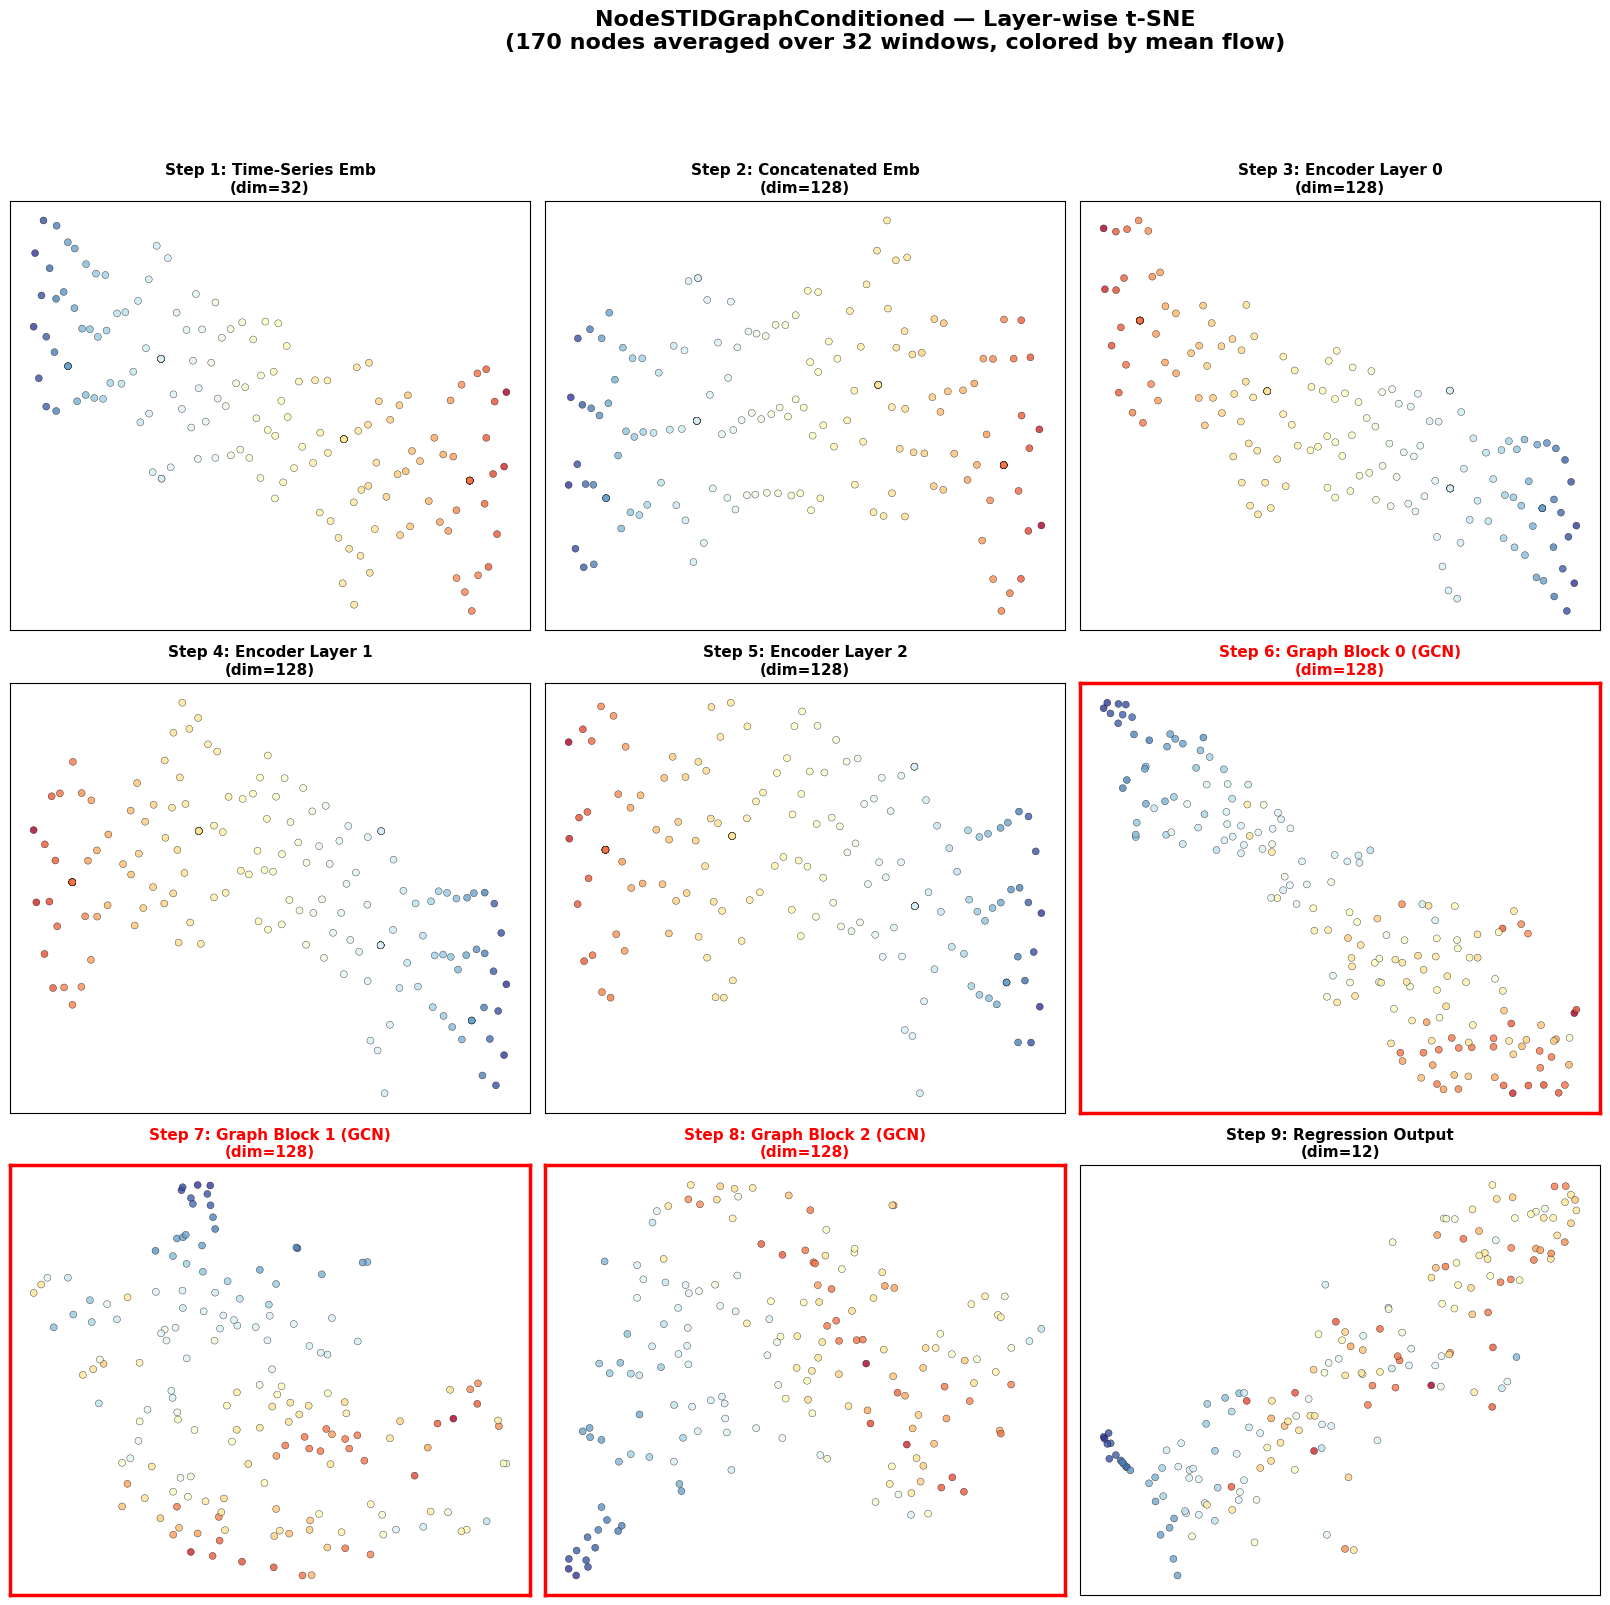

Saved: notebooks/gc_tsne_layerwise.png

Note: ToD, DoW, Dataset-ID embeddings excluded (shared across all nodes).


In [47]:
# ===================== Graph Conditioned: Layer-wise t-SNE =====================
# Skip ToD/DoW/DatasetID — they are shared across all nodes at the same timestep,
# so averaging over windows still yields identical vectors for all 170 nodes.
layer_names_gc = [
    'Time-Series Emb', 'Concatenated Emb',
    'Encoder Layer 0', 'Encoder Layer 1', 'Encoder Layer 2',
    'Graph Block 0', 'Graph Block 1', 'Graph Block 2', 'Regression Output'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle('NodeSTIDGraphConditioned — Layer-wise t-SNE\n(170 nodes averaged over 32 windows, colored by mean flow)',
             fontsize=16, fontweight='bold', y=1.0)

for idx, (name, ax) in enumerate(zip(layer_names_gc, axes.flat)):
    # gc_reps[name] shape: [B, N, D] — average over batch
    feat = gc_reps[name].mean(dim=0).cpu().numpy()  # [170, D]
    
    if feat.shape[1] < 2:
        ax.text(0.5, 0.5, f'{name}\n(dim={feat.shape[1]}, skip)',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title(name, fontsize=11)
        continue
    
    tsne_result = compute_tsne(feat)
    scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1],
                         c=node_flow_norm, cmap='RdYlBu_r', s=25, alpha=0.8, edgecolors='k', linewidths=0.3)
    
    # Highlight transition from backbone to graph
    if 'Graph Block' in name:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2.5)
        ax.set_title(f'Step {idx+1}: {name} (GCN)\n(dim={feat.shape[1]})',
                     fontsize=11, fontweight='bold', color='red')
    else:
        ax.set_title(f'Step {idx+1}: {name}\n(dim={feat.shape[1]})', fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

# cbar = fig.colorbar(scatter, ax=axes, shrink=0.6, pad=0.04)
# cbar.set_label('Mean Traffic Flow (normalized)', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.90, 0.95])
plt.savefig('notebooks/gc_tsne_layerwise.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/gc_tsne_layerwise.png')
print('\nNote: ToD, DoW, Dataset-ID embeddings excluded (shared across all nodes).')

## 7. Side-by-Side: Backbone vs Graph Conditioned

Direct comparison at matched layers to see the effect of graph conditioning.

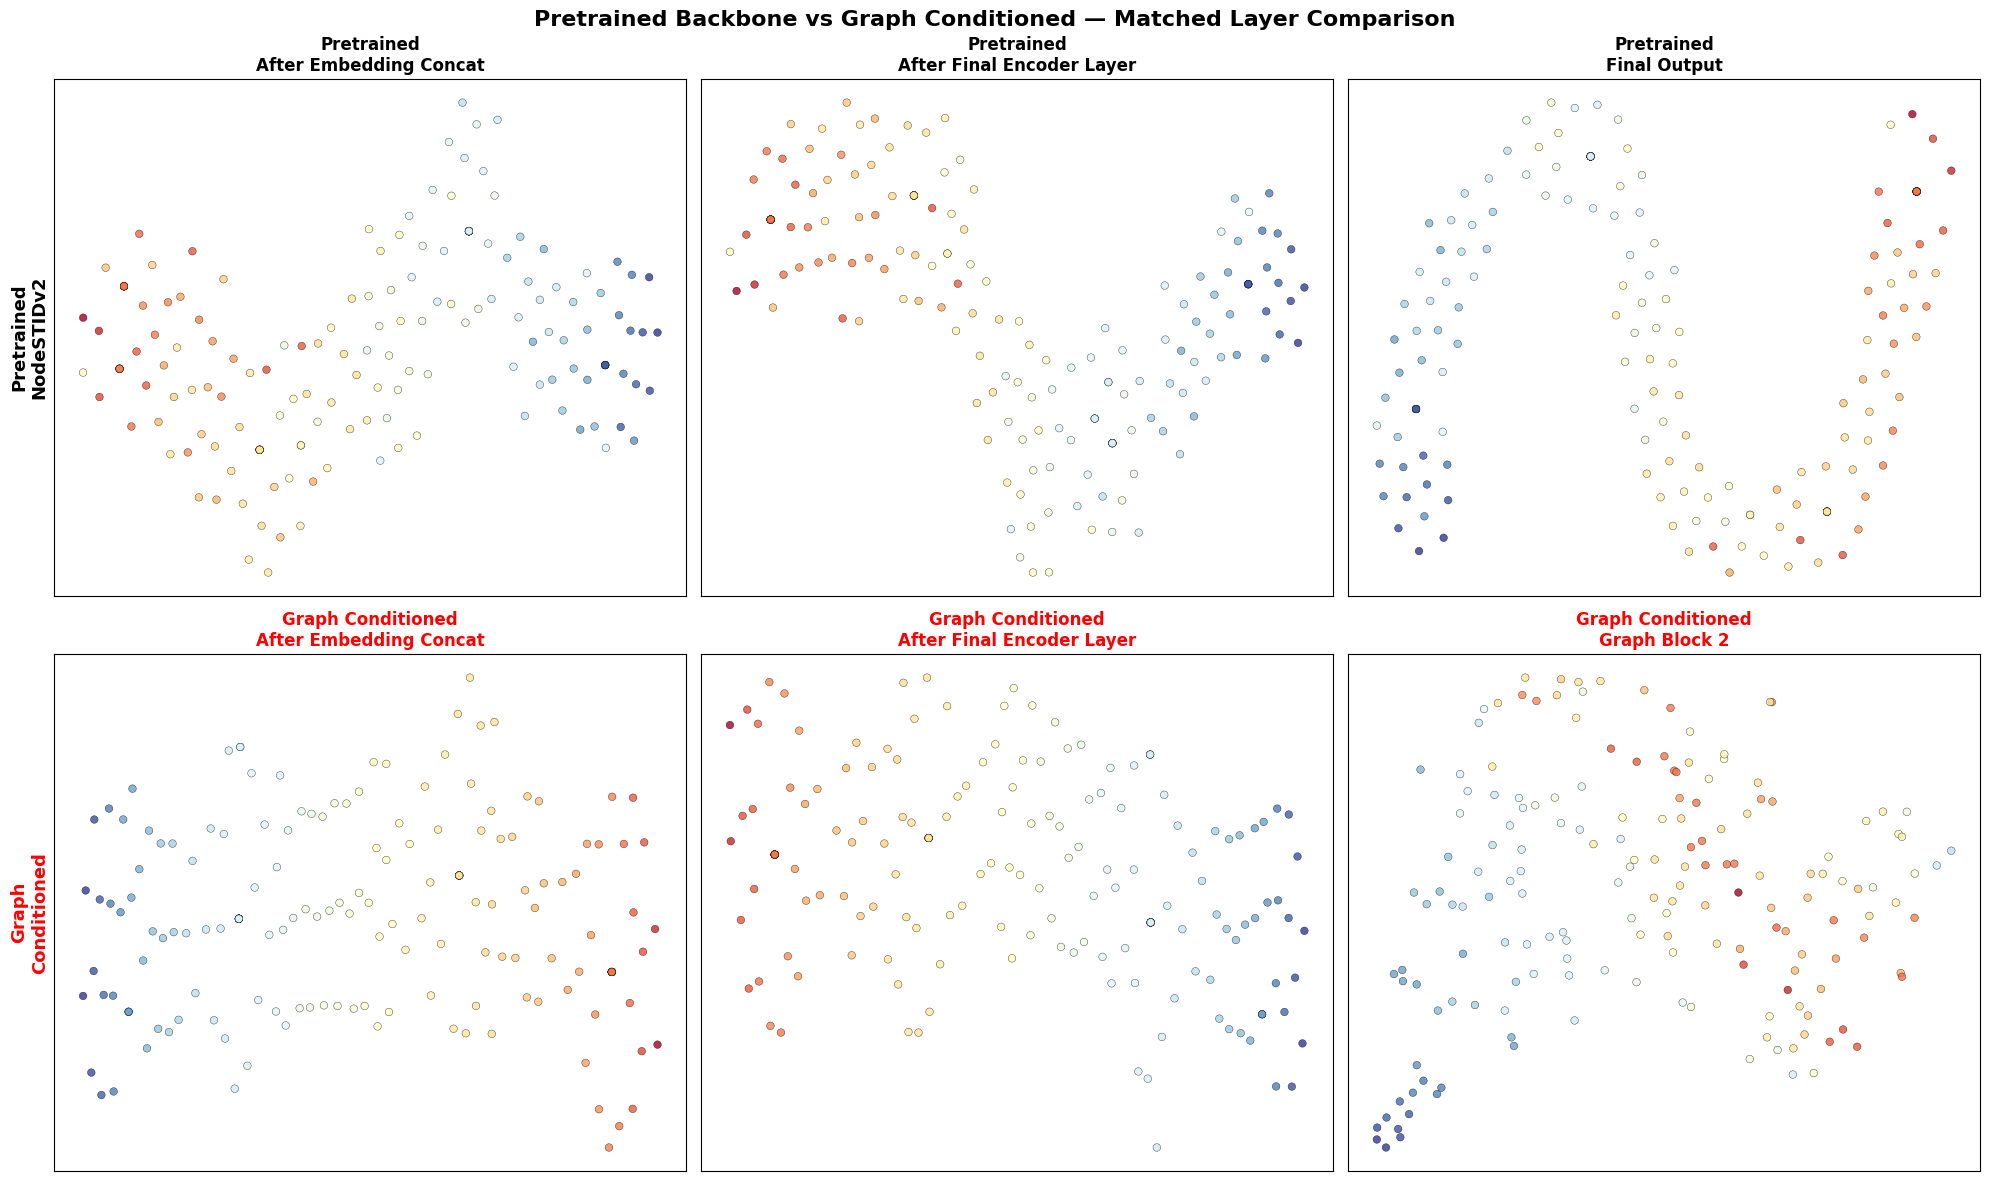

Saved: notebooks/side_by_side_comparison.png


In [39]:
# ===================== Side-by-side comparison =====================
compare_layers = [
    ('Concatenated Emb', 'Input to Encoder'),
    ('Encoder Layer 2', 'Backbone Output (after Encoder)'),
    ('Encoder Layer 2', 'Before Graph Conditioning'),  # same as above for GC
]
# For pretrained: entries from pretrained_reps (shape [170, D])
# For GC: entries from gc_reps (shape [B, N, D], take mean)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Pretrained Backbone vs Graph Conditioned — Matched Layer Comparison',
             fontsize=16, fontweight='bold')

comparison_pairs = [
    ('Concatenated Emb', 'After Embedding Concat'),
    ('Encoder Layer 2', 'After Final Encoder Layer'),
    ('Regression Output', 'Final Output'),
]

for col, (layer_name, title_label) in enumerate(comparison_pairs):
    # Top row: Pretrained backbone
    feat_pre = pretrained_reps[layer_name].cpu().numpy()
    if feat_pre.shape[1] >= 2:
        tsne_pre = compute_tsne(feat_pre)
        axes[0, col].scatter(tsne_pre[:, 0], tsne_pre[:, 1],
                             c=node_flow_norm, cmap='RdYlBu_r', s=30, alpha=0.8,
                             edgecolors='k', linewidths=0.3)
    axes[0, col].set_title(f'Pretrained\n{title_label}', fontsize=12, fontweight='bold')
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])
    
    # Bottom row: Graph Conditioned
    if layer_name == 'Regression Output':
        # For GC, use Graph Block 2 as the meaningful final hidden state
        gc_layer = 'Graph Block 2'
    else:
        gc_layer = layer_name
    
    feat_gc = gc_reps[gc_layer].mean(dim=0).cpu().numpy()
    if feat_gc.shape[1] >= 2:
        tsne_gc = compute_tsne(feat_gc)
        axes[1, col].scatter(tsne_gc[:, 0], tsne_gc[:, 1],
                             c=node_flow_norm, cmap='RdYlBu_r', s=30, alpha=0.8,
                             edgecolors='k', linewidths=0.3)
    gc_title = gc_layer if gc_layer != layer_name else title_label
    axes[1, col].set_title(f'Graph Conditioned\n{gc_title}', fontsize=12,
                           fontweight='bold', color='red')
    axes[1, col].set_xticks([])
    axes[1, col].set_yticks([])

axes[0, 0].set_ylabel('Pretrained\nNodeSTIDv2', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Graph\nConditioned', fontsize=13, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('notebooks/side_by_side_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/side_by_side_comparison.png')

## 8. Adaptive Adjacency Matrix Visualization

The graph conditioned model learns an adaptive adjacency matrix from `nodevec1` and `nodevec2`.  
Let's visualize it and compare with the original adjacency.

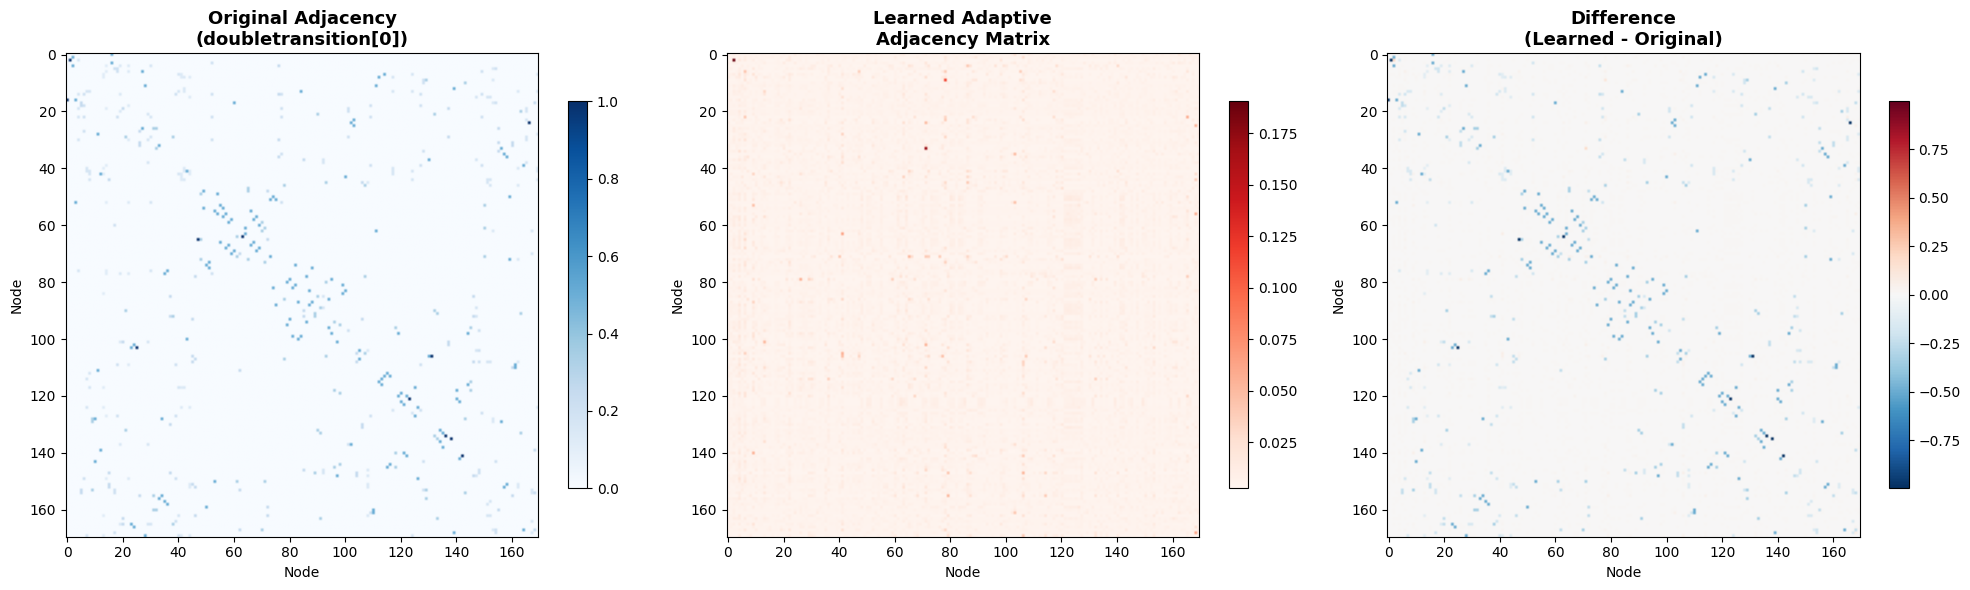

Saved: notebooks/adjacency_comparison.png


In [40]:
# ===================== Adaptive Adjacency =====================
with torch.no_grad():
    adp = torch.softmax(torch.relu(
        gc_model.nodevec1 @ gc_model.nodevec2), dim=1).cpu().numpy()

# Original adjacency (first support)
orig_adj = gc_model.support_0.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Original adjacency
im0 = axes[0].imshow(orig_adj, cmap='Blues', aspect='auto')
axes[0].set_title('Original Adjacency\n(doubletransition[0])', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Node')
axes[0].set_ylabel('Node')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Learned adaptive adjacency
im1 = axes[1].imshow(adp, cmap='Reds', aspect='auto')
axes[1].set_title('Learned Adaptive\nAdjacency Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Node')
axes[1].set_ylabel('Node')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Difference
diff = adp - orig_adj
im2 = axes[2].imshow(diff, cmap='RdBu_r', aspect='auto',
                      vmin=-np.abs(diff).max(), vmax=np.abs(diff).max())
axes[2].set_title('Difference\n(Learned - Original)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Node')
axes[2].set_ylabel('Node')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.savefig('notebooks/adjacency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/adjacency_comparison.png')

## 9. Node Embedding Space: Learned vs Graph Structure

Visualize the learned adaptive node vectors (`nodevec1`) using t-SNE,  
compared with graphs derived from adjacency structure.

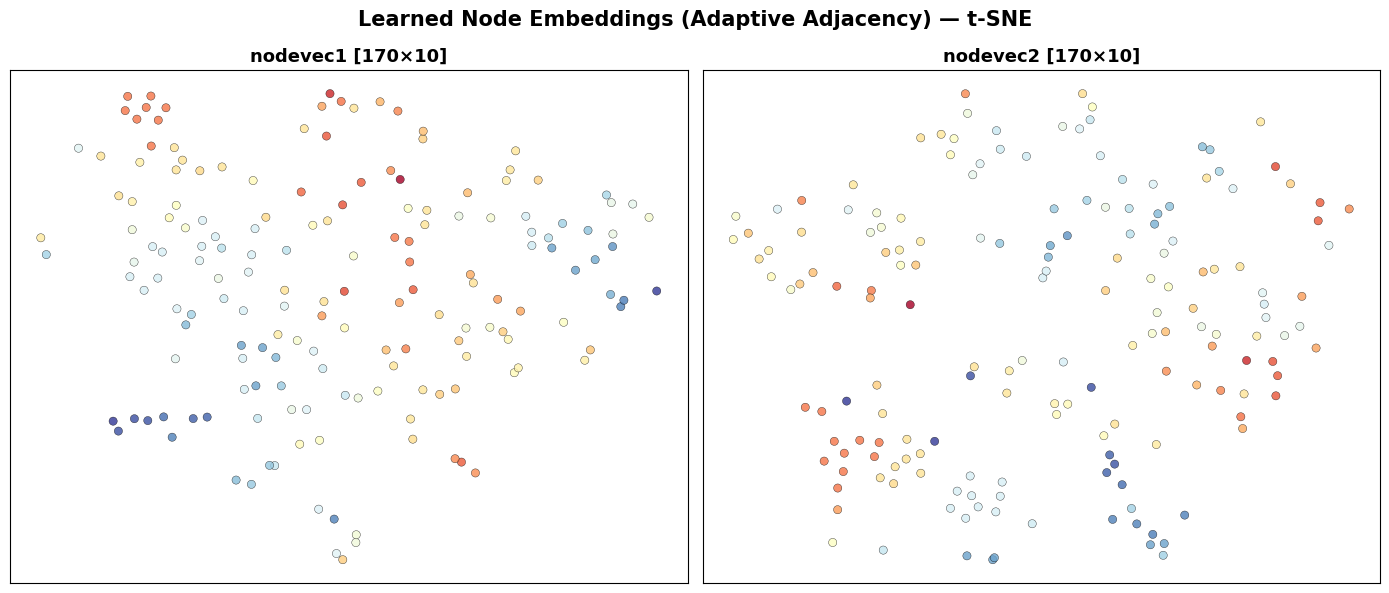

Saved: notebooks/node_embeddings_tsne.png


In [48]:
# ===================== Node embedding t-SNE =====================
nodevec1 = gc_model.nodevec1.detach().cpu().numpy()  # [170, 10]
nodevec2 = gc_model.nodevec2.detach().cpu().numpy().T  # [170, 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Learned Node Embeddings (Adaptive Adjacency) — t-SNE',
             fontsize=15, fontweight='bold')

for i, (vec, name) in enumerate([(nodevec1, 'nodevec1'), (nodevec2, 'nodevec2')]):
    tsne = compute_tsne(vec, perplexity=20)
    sc = axes[i].scatter(tsne[:, 0], tsne[:, 1], c=node_flow_norm,
                         cmap='RdYlBu_r', s=35, alpha=0.8, edgecolors='k', linewidths=0.3)
    axes[i].set_title(f'{name} [170×10]', fontsize=13, fontweight='bold')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

# plt.colorbar(sc, ax=axes, shrink=0.7, label='Mean Traffic Flow (norm.)')
plt.tight_layout()
plt.savefig('notebooks/node_embeddings_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/node_embeddings_tsne.png')

## 10. Per-Window Variance: Backbone vs Graph Conditioned

For each batch window, measure how much variance exists across node representations.  
Graph conditioning should **increase** inter-node variance (nodes become more distinct)  
while the backbone treats nodes independently.

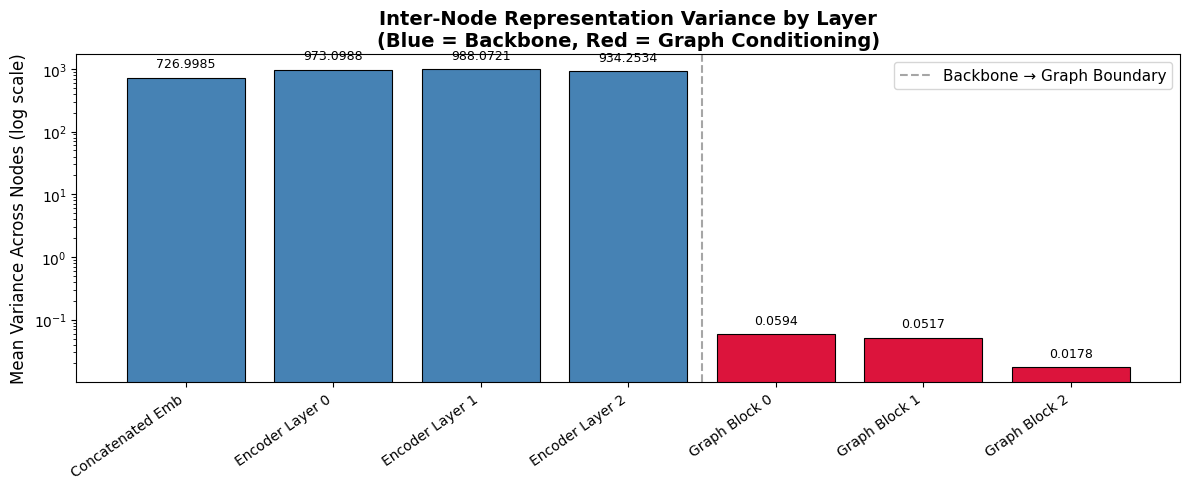

Saved: notebooks/variance_analysis.png


In [42]:
# ===================== Variance analysis across layers =====================
gc_layer_names = [
    'Concatenated Emb', 'Encoder Layer 0', 'Encoder Layer 1', 'Encoder Layer 2',
    'Graph Block 0', 'Graph Block 1', 'Graph Block 2'
]

# For each layer, compute mean variance across nodes for each batch window
mean_variances = []
for name in gc_layer_names:
    feat = gc_reps[name].cpu().numpy()  # [B, N, D]
    # Variance across nodes for each batch, averaged over dims and batches
    var_per_window = np.var(feat, axis=1).mean()  # scalar
    mean_variances.append(var_per_window)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue']*4 + ['crimson']*3
bars = ax.bar(range(len(gc_layer_names)), mean_variances, color=colors, edgecolor='k', linewidth=0.8)
ax.set_xticks(range(len(gc_layer_names)))
ax.set_xticklabels(gc_layer_names, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Mean Variance Across Nodes (log scale)', fontsize=12)
ax.set_title('Inter-Node Representation Variance by Layer\n(Blue = Backbone, Red = Graph Conditioning)',
             fontsize=14, fontweight='bold')
ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.7, label='Backbone → Graph Boundary')
ax.legend(fontsize=11)

# Use log scale so both backbone (~700) and graph block (~0.05) are visible
ax.set_yscale('log')

# Annotate values above each bar
for bar, val in zip(bars, mean_variances):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('notebooks/variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/variance_analysis.png')

## 11. Cosine Similarity Between Nodes Across Layers

How similar are node representations at each layer?  
The backbone treats nodes independently → high diversity.  
Graph conditioning should create clusters of similar nodes.

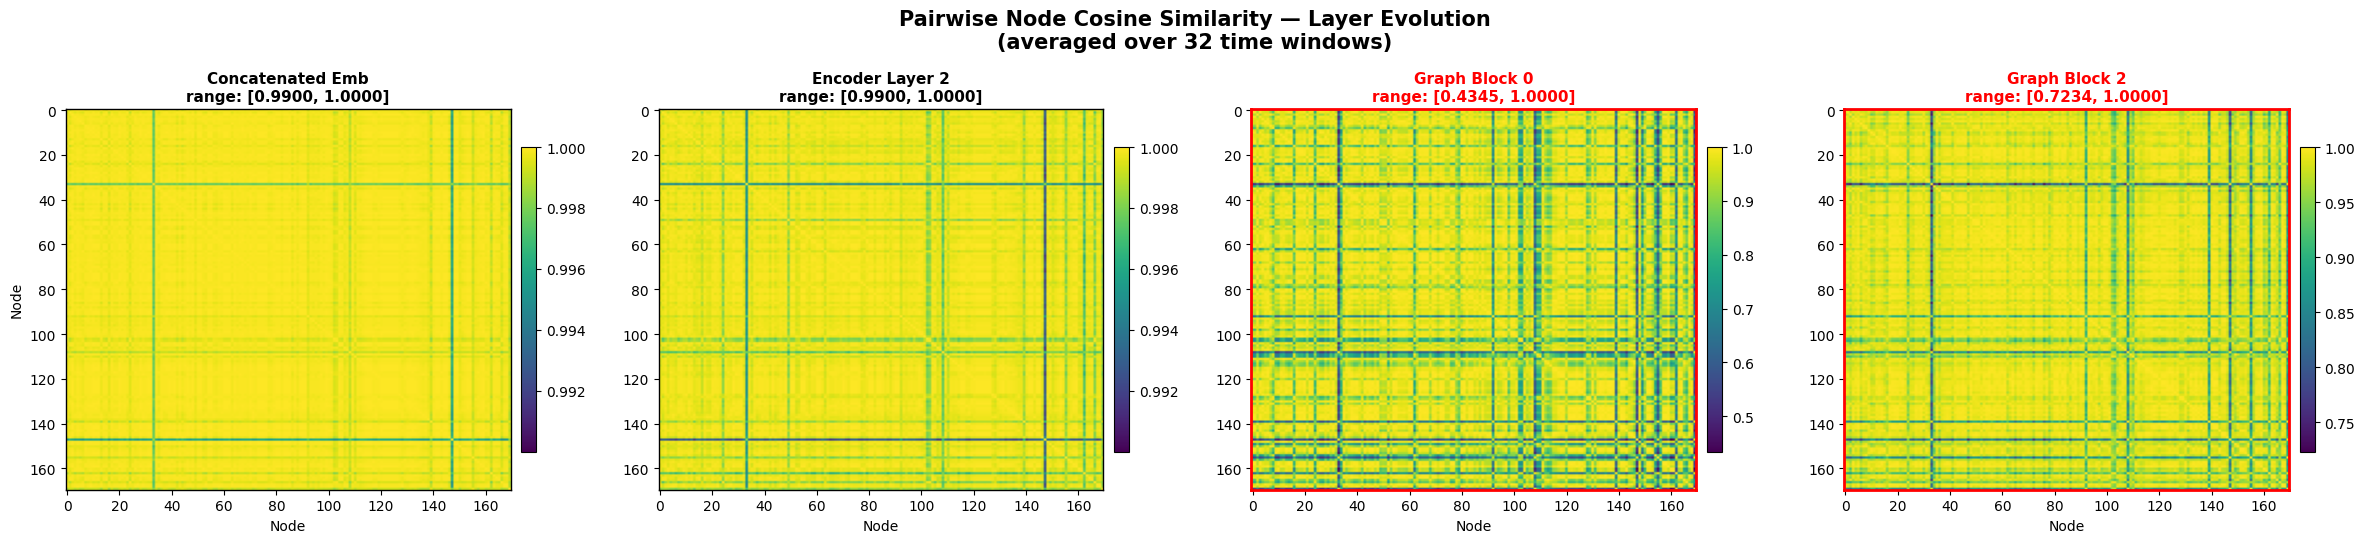

Saved: notebooks/cosine_similarity_layers.png


In [43]:
# ===================== Cosine similarity heatmaps =====================
from sklearn.metrics.pairwise import cosine_similarity

vis_layers = ['Concatenated Emb', 'Encoder Layer 2', 'Graph Block 0', 'Graph Block 2']

fig, axes = plt.subplots(1, 4, figsize=(24, 5.5))
fig.suptitle('Pairwise Node Cosine Similarity — Layer Evolution\n(averaged over 32 time windows)',
             fontsize=15, fontweight='bold')

for i, name in enumerate(vis_layers):
    feat = gc_reps[name].mean(dim=0).cpu().numpy()  # [170, D]
    sim = cosine_similarity(feat)  # [170, 170]
    
    # Use adaptive color range per subplot so structure is visible
    # (backbone layers have cos sim ~1.0 everywhere; fixed [-1,1] hides detail)
    vmin_val = sim.min()
    vmax_val = sim.max()
    # Add small padding to avoid degenerate range
    if vmax_val - vmin_val < 0.01:
        vmin_val = vmax_val - 0.01
    
    im = axes[i].imshow(sim, cmap='viridis', vmin=vmin_val, vmax=vmax_val, aspect='auto')
    # Per-subplot colorbar to show actual range
    fig.colorbar(im, ax=axes[i], shrink=0.8, pad=0.02)
    
    border_color = 'red' if 'Graph' in name else 'black'
    for spine in axes[i].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2 if 'Graph' in name else 1)
    axes[i].set_title(f'{name}\nrange: [{vmin_val:.4f}, {vmax_val:.4f}]', fontsize=11, fontweight='bold',
                      color='red' if 'Graph' in name else 'black')
    axes[i].set_xlabel('Node')
    if i == 0:
        axes[i].set_ylabel('Node')

plt.tight_layout()
plt.savefig('notebooks/cosine_similarity_layers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/cosine_similarity_layers.png')

## 12. Graph Block Decomposition: GCN vs MLP Effect

Each Graph Block has: GCN → Residual+Norm → MLP → Residual+Norm.  
Let's hook into the internals to see the GCN effect vs MLP effect separately.

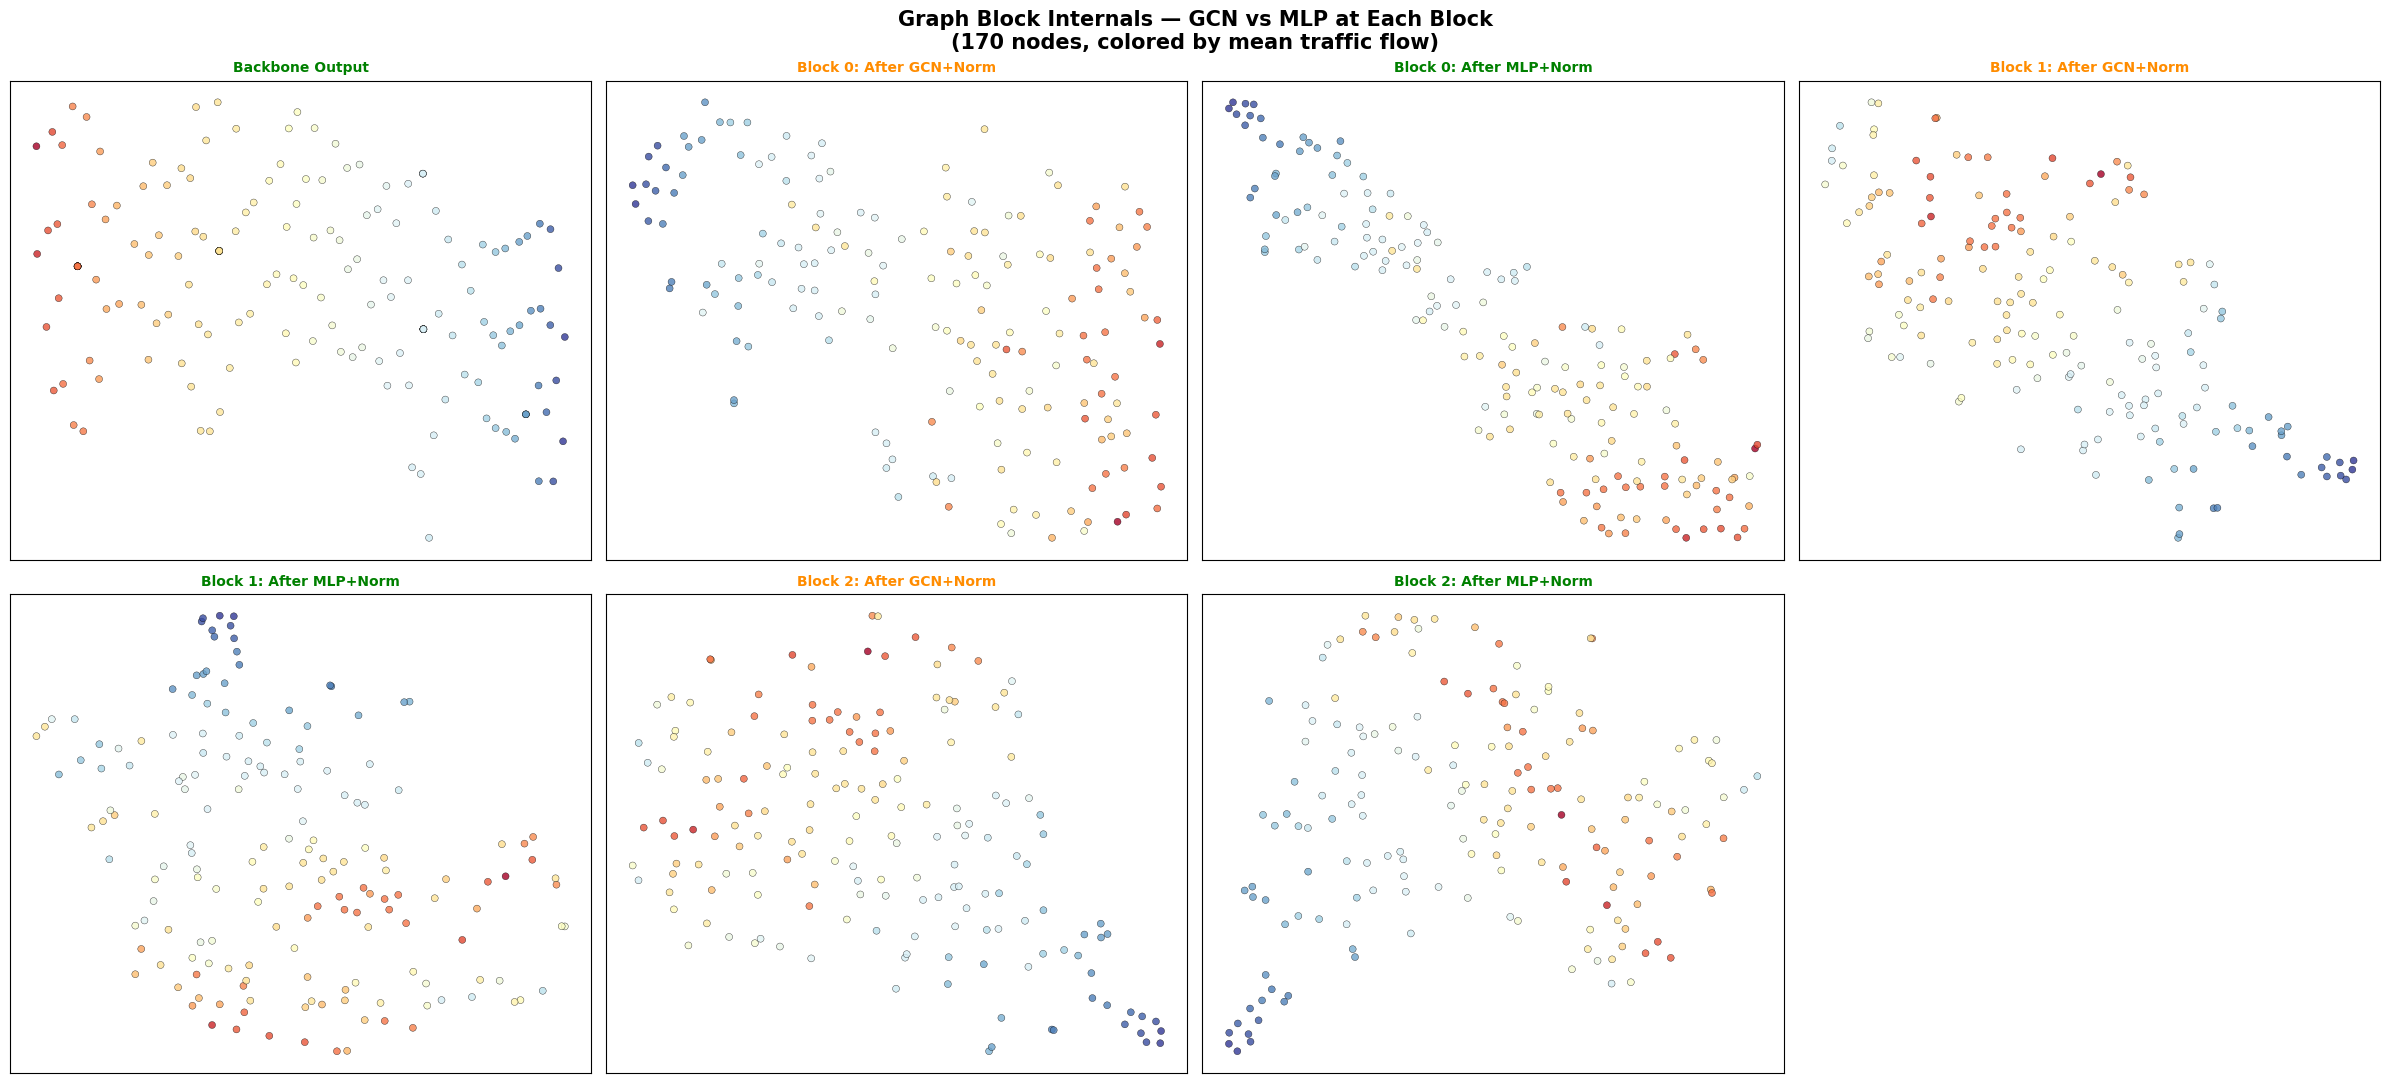

Saved: notebooks/graph_block_decomposition.png


In [44]:
# ===================== Decompose Graph Block internals =====================
def extract_graph_block_internals(model, history_data):
    """
    Extract representations at sub-steps within each GraphConditioningBlock:
    - After GCN (before MLP)
    - After GCN+Norm
    - After MLP+Norm (full block output)
    """
    reps = {}
    B, L, N, C = history_data.shape
    
    with torch.no_grad():
        # Run backbone
        hidden = model._backbone_forward_per_node(history_data)
        if model.proj is not None:
            hidden = model.proj(hidden)
        
        reps['Backbone Output'] = hidden.squeeze(-1).permute(0, 2, 1).clone()
        supports = model._get_supports()
        
        for i, block in enumerate(model.graph_blocks):
            # Sub-step 1: GCN + residual + norm
            residual = hidden
            gcn_out = block.gcn(hidden, supports)
            gcn_res = gcn_out + residual
            gcn_normed = gcn_res.permute(0, 2, 3, 1)  # [B, N, 1, C]
            gcn_normed = block.norm(gcn_normed)
            reps[f'Block {i}: After GCN+Norm'] = gcn_normed.squeeze(2).clone()  # [B, N, C]
            
            # Sub-step 2: MLP + residual + norm
            residual2 = gcn_normed
            mlp_out = block.mlp(gcn_normed)
            mlp_res = mlp_out + residual2
            mlp_normed = block.norm2(mlp_res)
            reps[f'Block {i}: After MLP+Norm'] = mlp_normed.squeeze(2).clone()  # [B, N, C]
            
            hidden = mlp_normed.permute(0, 3, 1, 2)  # [B, C, N, 1]
    
    return reps

block_reps = extract_graph_block_internals(gc_model, batch)

# Plot
block_layer_names = list(block_reps.keys())
fig, axes = plt.subplots(2, 4, figsize=(24, 11))
fig.suptitle('Graph Block Internals — GCN vs MLP at Each Block\n'
             '(170 nodes, colored by mean traffic flow)',
             fontsize=15, fontweight='bold')

# Flatten to iterate; pad if needed
axes_flat = axes.flat
for idx in range(len(block_layer_names)):
    ax = axes_flat[idx]
    name = block_layer_names[idx]
    feat = block_reps[name].mean(dim=0).cpu().numpy()  # [170, D] or [170, C]
    
    if feat.ndim == 1 or feat.shape[1] < 2:
        ax.text(0.5, 0.5, f'{name}\nskip', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(name, fontsize=10)
        continue
    
    tsne = compute_tsne(feat)
    color = 'darkorange' if 'GCN' in name else 'green'
    ax.scatter(tsne[:, 0], tsne[:, 1], c=node_flow_norm, cmap='RdYlBu_r',
               s=25, alpha=0.8, edgecolors='k', linewidths=0.3)
    ax.set_title(name, fontsize=10, fontweight='bold', color=color)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused subplots
for idx in range(len(block_layer_names), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.savefig('notebooks/graph_block_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/graph_block_decomposition.png')

## 13. Temporal Embedding Analysis

Visualize the learned temporal embeddings (Time-of-Day and Day-of-Week) from the pretrained model.

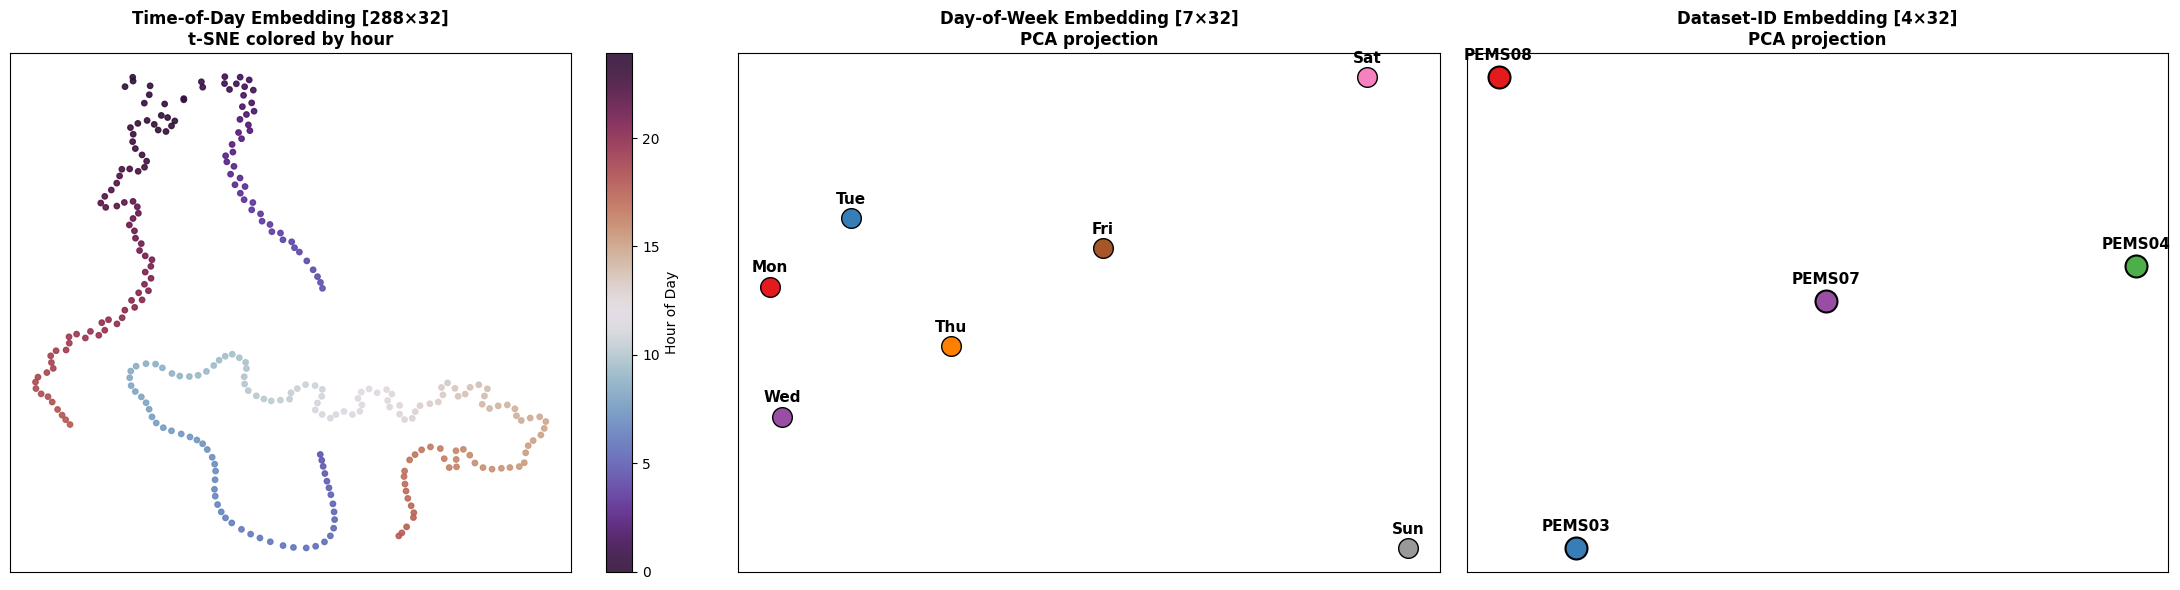

Saved: notebooks/temporal_embeddings.png


In [45]:
# ===================== Temporal Embedding Analysis =====================
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Time-of-Day embedding ---
tod_emb = pretrained_model.time_in_day_emb.detach().cpu().numpy()  # [288, 32]
tsne_tod = compute_tsne(tod_emb, perplexity=25)
tod_colors = np.arange(288)  # 0-287 time slots
hours = tod_colors / 12.0  # convert to hours (5-min intervals)

sc0 = axes[0].scatter(tsne_tod[:, 0], tsne_tod[:, 1], c=hours,
                       cmap='twilight_shifted', s=15, alpha=0.9)
axes[0].set_title('Time-of-Day Embedding [288×32]\nt-SNE colored by hour',
                   fontsize=12, fontweight='bold')
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(sc0, ax=axes[0], label='Hour of Day')

# --- Day-of-Week embedding ---
dow_emb = pretrained_model.day_in_week_emb.detach().cpu().numpy()  # [7, 32]
# PCA for 7 points (t-SNE not meaningful for 7 points)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
dow_2d = pca.fit_transform(dow_emb)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_colors = plt.cm.Set1(np.linspace(0, 1, 7))

for i, (x, y) in enumerate(dow_2d):
    axes[1].scatter(x, y, c=[day_colors[i]], s=200, edgecolors='k', linewidths=1, zorder=3)
    axes[1].annotate(day_names[i], (x, y), fontsize=11, fontweight='bold',
                     ha='center', va='bottom', xytext=(0, 8),
                     textcoords='offset points')

axes[1].set_title('Day-of-Week Embedding [7×32]\nPCA projection',
                   fontsize=12, fontweight='bold')
axes[1].set_xticks([])
axes[1].set_yticks([])

# --- Dataset ID embedding ---
dsid_emb = pretrained_model.dataset_id_emb.detach().cpu().numpy()  # [4, 32]
dsid_2d = PCA(n_components=2).fit_transform(dsid_emb)
ds_names = ['PEMS08', 'PEMS03', 'PEMS04', 'PEMS07']
ds_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for i, (x, y) in enumerate(dsid_2d):
    axes[2].scatter(x, y, c=ds_colors[i], s=250, edgecolors='k', linewidths=1.5, zorder=3)
    axes[2].annotate(ds_names[i], (x, y), fontsize=11, fontweight='bold',
                     ha='center', va='bottom', xytext=(0, 10),
                     textcoords='offset points')

axes[2].set_title('Dataset-ID Embedding [4×32]\nPCA projection',
                   fontsize=12, fontweight='bold')
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.savefig('notebooks/temporal_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/temporal_embeddings.png')

## 14. Representation Norms Across Layers

Track how the L2 norm of representations evolves through the network.  
This reveals how information magnitude changes at each processing stage.

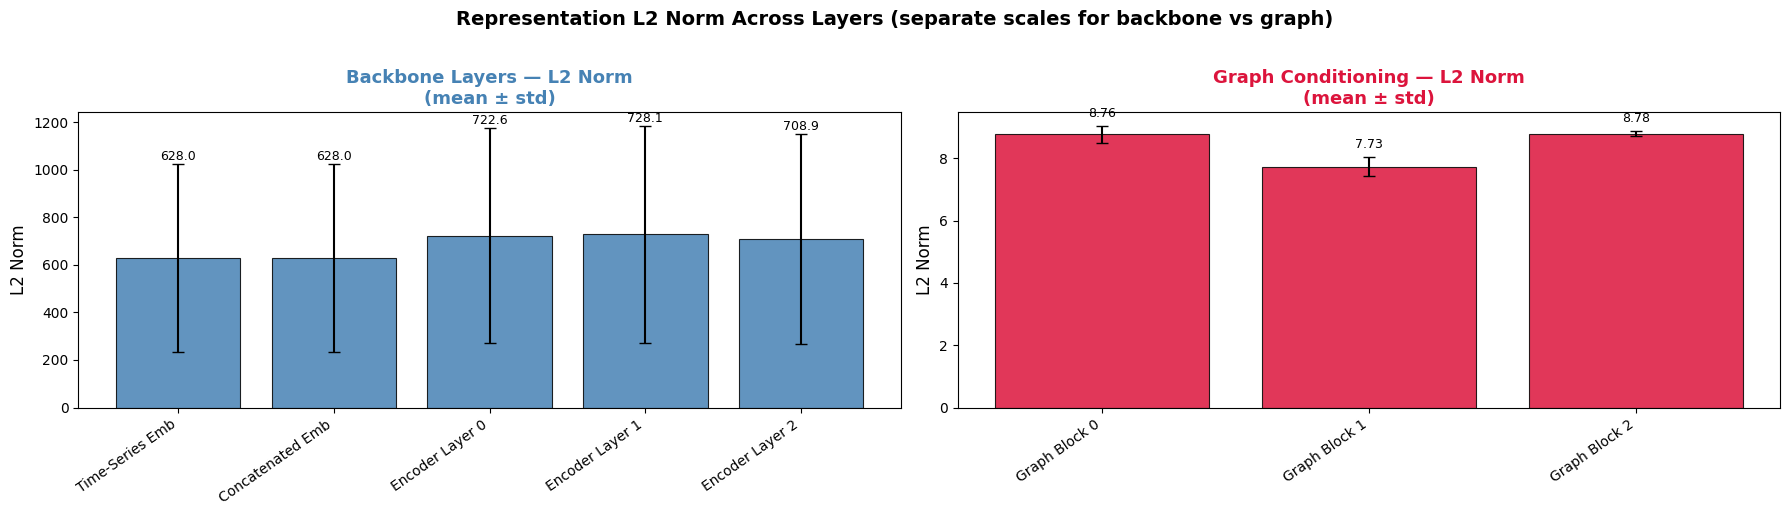

Saved: notebooks/norm_evolution.png


In [46]:
# ===================== L2 Norm evolution =====================
gc_flow_layers = [
    'Time-Series Emb', 'Concatenated Emb',
    'Encoder Layer 0', 'Encoder Layer 1', 'Encoder Layer 2',
    'Graph Block 0', 'Graph Block 1', 'Graph Block 2'
]

norms_mean = []
norms_std = []
for name in gc_flow_layers:
    feat = gc_reps[name].cpu().numpy()  # [B, N, D]
    l2 = np.linalg.norm(feat, axis=-1)  # [B, N]
    norms_mean.append(l2.mean())
    norms_std.append(l2.std())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# --- Left: Backbone layers (linear scale) ---
backbone_idx = list(range(5))  # first 5 layers
backbone_names = [gc_flow_layers[i] for i in backbone_idx]
backbone_means = [norms_mean[i] for i in backbone_idx]
backbone_stds = [norms_std[i] for i in backbone_idx]

ax1.bar(range(len(backbone_idx)), backbone_means, yerr=backbone_stds,
        color='steelblue', edgecolor='k', linewidth=0.8, capsize=4, alpha=0.85)
ax1.set_xticks(range(len(backbone_idx)))
ax1.set_xticklabels(backbone_names, rotation=35, ha='right', fontsize=10)
ax1.set_ylabel('L2 Norm', fontsize=12)
ax1.set_title('Backbone Layers — L2 Norm\n(mean ± std)', fontsize=13, fontweight='bold', color='steelblue')
for j, (m, s) in enumerate(zip(backbone_means, backbone_stds)):
    ax1.text(j, m + s + 5, f'{m:.1f}', ha='center', va='bottom', fontsize=9)

# --- Right: Graph Conditioning layers (linear scale, own y-axis) ---
graph_idx = list(range(5, 8))  # last 3 layers
graph_names = [gc_flow_layers[i] for i in graph_idx]
graph_means = [norms_mean[i] for i in graph_idx]
graph_stds = [norms_std[i] for i in graph_idx]

ax2.bar(range(len(graph_idx)), graph_means, yerr=graph_stds,
        color='crimson', edgecolor='k', linewidth=0.8, capsize=4, alpha=0.85)
ax2.set_xticks(range(len(graph_idx)))
ax2.set_xticklabels(graph_names, rotation=35, ha='right', fontsize=10)
ax2.set_ylabel('L2 Norm', fontsize=12)
ax2.set_title('Graph Conditioning — L2 Norm\n(mean ± std)', fontsize=13, fontweight='bold', color='crimson')
for j, (m, s) in enumerate(zip(graph_means, graph_stds)):
    ax2.text(j, m + s + 0.2, f'{m:.2f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Representation L2 Norm Across Layers (separate scales for backbone vs graph)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/norm_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/norm_evolution.png')

## 15. Summary

### Key observations to look for:

1. **Pretrained Backbone (NodeSTIDv2):**
   - Since each node is processed independently (no spatial info), the t-SNE should show that nodes with similar **temporal patterns** cluster together.
   - The encoder layers progressively transform embeddings — nodes may become more/less clustered.
   - Time-of-day embeddings should show a **circular/cyclical** structure (nearby hours are similar).
   - Dataset ID embeddings show how the model distinguishes different datasets.

2. **Graph Conditioned Model:**
   - Backbone layers (before graph blocks) should look similar to pretrained t-SNE — same weights.
   - **Graph Block layers** are where the magic happens: GCN mixes neighbor information, so nodes that are **geographically close** should cluster together.
   - The cosine similarity matrices should show block-diagonal patterns emerging after GCN.
   - Adaptive adjacency should capture relationships not present in the original distance-based adjacency.

3. **Variance analysis:** Graph conditioning should redistribute variance — making some groups tighter while separating others.